**Imports, Drive mount, and paths**

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow import keras
from tensorflow.keras import mixed_precision

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

sns.set(style="whitegrid", context="notebook")

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

mixed_precision.set_global_policy('mixed_float16')
print('Mixed precision enabled. GPU will be leveraged.')

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision enabled. GPU will be leveraged.


In [3]:
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Paths and constants**

In [5]:
# Base project directory
BASE_DIR = "/content/drive/MyDrive/Cross-Dataset Generalization Thesis"

EUROSAT_DIR = os.path.join(BASE_DIR, "eurosat")
UCM_DIR     = os.path.join(BASE_DIR, "uc_merced")

# Shared Day-3 few-shot output directories (same as first notebook)
FEWSHOT_DIR     = os.path.join(BASE_DIR, "few_shot")
FEWSHOT_METRICS = os.path.join(FEWSHOT_DIR, "metrics")
FEWSHOT_NPY     = os.path.join(FEWSHOT_DIR, "npy")
FEWSHOT_FIGS    = os.path.join(FEWSHOT_DIR, "figs")
FEWSHOT_HISTORY = os.path.join(FEWSHOT_DIR, "history")

for d in [FEWSHOT_DIR, FEWSHOT_METRICS, FEWSHOT_NPY, FEWSHOT_FIGS, FEWSHOT_HISTORY]:
    os.makedirs(d, exist_ok=True)

print("FEWSHOT_DIR:", FEWSHOT_DIR)
print("Subdirs:", os.listdir(FEWSHOT_DIR))

FEWSHOT_DIR: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/few_shot
Subdirs: ['metrics', 'npy', 'figs', 'history', 'day3_fewshot_eurosat_to_ucm_resnet50.csv']


**EuroSAT loading + split (unbatched, then batched once)**

In [6]:
import tensorflow_datasets as tfds

IMG_SIZE   = (128, 128)
BATCH_SIZE = 64
TARGET_SUBSET = 3_000  # you already use 5K; reduce further if RAM is tight

def preprocess_image(example):
    image = tf.image.resize(example["image"], IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = example["label"]
    return image, label

builder_es = tfds.builder("eurosat")
builder_es.download_and_prepare()

# Full EuroSAT train split, preprocessed
full_es = builder_es.as_dataset(split="train", shuffle_files=False)
full_es = full_es.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

num_total_es = builder_es.info.splits["train"].num_examples
print("EuroSAT total images (original):", num_total_es)

# Subsample to TARGET_SUBSET
full_es = full_es.shuffle(
    buffer_size=num_total_es,
    seed=42,
    reshuffle_each_iteration=False,
)

if num_total_es > TARGET_SUBSET:
    full_es = full_es.take(TARGET_SUBSET)
    num_total_es = TARGET_SUBSET

print("Using EuroSAT subset size:", num_total_es)

# 60/20/20 split on the subset
train_size_es = int(0.6 * num_total_es)
val_size_es   = int(0.2 * num_total_es)
test_size_es  = num_total_es - train_size_es - val_size_es

es_train_raw = full_es.take(train_size_es)
es_val_raw   = full_es.skip(train_size_es).take(val_size_es)
es_test_raw  = full_es.skip(train_size_es + val_size_es)

es_train_raw = es_train_raw.cache()
es_val_raw   = es_val_raw.cache()
es_test_raw  = es_test_raw.cache()

num_classes_es = builder_es.info.features["label"].num_classes
class_names_es = builder_es.info.features["label"].names

print("EuroSAT classes:", num_classes_es,
      "Train/Val/Test:", train_size_es, val_size_es, test_size_es)

EuroSAT total images (original): 27000
Using EuroSAT subset size: 3000
EuroSAT classes: 10 Train/Val/Test: 1800 600 600


In [7]:
# Build label array only (no full image tensor array)
train_labels_list = []
for _, lab in es_train_raw:
    train_labels_list.append(int(lab.numpy()))

train_labels_arr = np.array(train_labels_list, dtype=np.int64)
print("Train labels shape:", train_labels_arr.shape)

indices_per_class = {c: [] for c in range(num_classes_es)}
for idx, lab in enumerate(train_labels_arr):
    indices_per_class[int(lab)].append(idx)

{k: len(v) for k, v in indices_per_class.items()}

Train labels shape: (1800,)


{0: 206,
 1: 196,
 2: 199,
 3: 180,
 4: 149,
 5: 114,
 6: 183,
 7: 219,
 8: 168,
 9: 186}

In [8]:
def make_indexed_train_dataset():
    """
    Enumerated view of the EuroSAT training subset.
    Yields (index, (image, label)), where index is the position in es_train_raw.
    """
    return es_train_raw.enumerate()

**Few‑shot helpers (k ∈ {5, 10, 20})**

In [9]:
K_VALUES = [5, 10, 20]

def make_fewshot_dataset(k, val_per_class=0):
    """
    Build few-shot datasets directly from es_train_raw using indices_per_class.
    Only k * num_classes_es (+ val) images are materialized into NumPy.
    """
    train_idx = []
    val_idx = []

    for c in range(num_classes_es):
        all_idx = indices_per_class[c].copy()
        random.shuffle(all_idx)

        k_total = k + val_per_class
        if len(all_idx) < k_total:
            k_total = len(all_idx)

        selected = all_idx[:k_total]
        if val_per_class > 0:
            val_idx.extend(selected[:val_per_class])
            train_idx.extend(selected[val_per_class:])
        else:
            train_idx.extend(selected)

    train_idx = np.array(train_idx, dtype=np.int64)
    val_idx   = np.array(val_idx,   dtype=np.int64) if val_per_class > 0 else None

    x_train, y_train = [], []
    x_val,   y_val   = [], []

    indexed_ds = make_indexed_train_dataset()  # (i, (image, label))
    train_set = set(train_idx.tolist())
    val_set   = set(val_idx.tolist()) if val_idx is not None else set()

    for i, (img, lab) in indexed_ds:
        i_val = int(i.numpy())
        if i_val in train_set:
            x_train.append(img.numpy())
            y_train.append(int(lab.numpy()))
        elif i_val in val_set:
            x_val.append(img.numpy())
            y_val.append(int(lab.numpy()))

        if len(x_train) == len(train_set) and \
           (val_idx is None or len(x_val) == len(val_set)):
            break

    x_train = np.stack(x_train, axis=0)
    y_train = np.array(y_train, dtype=np.int64)

    if val_idx is not None and len(x_val) > 0:
        x_val = np.stack(x_val, axis=0)
        y_val = np.array(y_val, dtype=np.int64)
    else:
        x_val, y_val = None, None

    print(f"k={k}: train {x_train.shape[0]} samples, "
          f"val {0 if x_val is None else x_val.shape[0]} samples")
    return (x_train, y_train), (x_val, y_val)


In [10]:
def to_tf_dataset(x, y, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(y), reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

es_train_ds = es_train_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
es_val_ds   = es_val_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
es_test_ds  = es_test_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

for x_batch, y_batch in es_test_ds.take(1):
    print("EuroSAT test batch shape:", x_batch.shape, y_batch.shape)

EuroSAT test batch shape: (64, 128, 128, 3) (64,)


**Evaluation helpers (test = EuroSAT test set)**

In [11]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def reset_head_weights(model):
    last_dense = model.get_layer("eurosat_head")
    for var in last_dense.weights:
        var.assign(tf.random.normal(shape=var.shape, stddev=0.01))

def evaluate_on_test(model, dataset):
    all_y_true = []
    all_y_pred = []

    for x_batch, y_batch in dataset:
        logits = model.predict(x_batch, verbose=0)
        preds = np.argmax(logits, axis=1)
        all_y_true.append(y_batch.numpy())
        all_y_pred.append(preds)

    y_true = np.concatenate(all_y_true, axis=0)
    y_pred = np.concatenate(all_y_pred, axis=0)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes_es))

    return y_true, y_pred, acc, macro_f1, cm

def plot_confusion_matrix(cm, labels, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, cmap="Blues",
                xticklabels=labels, yticklabels=labels, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()

**Load UC Merced ResNet50 source model**

In [12]:
from tensorflow.keras import models, layers, optimizers, losses, metrics

UCM_MODEL_PATH = os.path.join(
    UCM_DIR, "models", "ucm_resnet50_full.keras"   # match your actual filename
)

base_model = tf.keras.models.load_model(UCM_MODEL_PATH)
base_model.summary()

Model: "resnet50_ucm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_ucm_resnet50        │ (None, 128, 128, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │         5,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,246,725 (275.60 MB)

 Trainable params: 24,064,533 (91.80 MB)

 Non-trainable params: 53,120 (207.50 KB)

 Optimizer params: 48,129,072 (183.60 MB)

**Build target‑adapted model (EuroSAT head)**

In [13]:
# feature extractor from UC Merced model (penultimate layer)
feature_extractor = tf.keras.Model(
    inputs=base_model.input,
    outputs=base_model.layers[-2].output,
)

# Freeze backbone
for layer in feature_extractor.layers:
    layer.trainable = False

# Optionally unfreeze last N layers
N_UNFREEZE = 10
for layer in feature_extractor.layers[-N_UNFREEZE:]:
    layer.trainable = True

inputs = feature_extractor.input
x = feature_extractor(inputs, training=False)
outputs = layers.Dense(num_classes_es, activation="softmax", name="eurosat_head")(x)

fewshot_model = tf.keras.Model(inputs=inputs, outputs=outputs)

fewshot_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=[metrics.SparseCategoricalAccuracy(name="accuracy")],
)

fewshot_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_ucm_resnet50        │ (None, 128, 128, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 256)            │    24,112,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ eurosat_head (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 24,061,706 (91.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

**Few‑shot runs and saving outputs (UC Merced → EuroSAT)**

In [14]:
MODEL_NAME   = "resnet50"
SRC_TO_TGT   = "ucm_to_eurosat"
VAL_PER_CLASS = 1
EPOCHS        = 8

results = []

for k in K_VALUES:
    print(f"\n===== Few-shot {SRC_TO_TGT}, k={k} =====")
    (x_train, y_train), (x_val, y_val) = make_fewshot_dataset(
        k, val_per_class=VAL_PER_CLASS
    )

    train_ds = to_tf_dataset(x_train, y_train, shuffle=True)
    val_ds = to_tf_dataset(x_val, y_val, shuffle=False) if x_val is not None else None

    reset_head_weights(fewshot_model)

    if val_ds is not None:
        history = fewshot_model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS,
            verbose=1,
        )
    else:
        history = fewshot_model.fit(
            train_ds,
            epochs=EPOCHS,
            verbose=1,
        )

    y_true, y_pred, acc, macro_f1, cm = evaluate_on_test(fewshot_model, es_test_ds)

    metrics_dict = {
        "source_dataset": "UC Merced",
        "target_dataset": "EuroSAT",
        "model": MODEL_NAME,
        "k_shot_per_class": int(k),
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
    }

    metrics_path = os.path.join(
        FEWSHOT_METRICS,
        f"fewshot_{SRC_TO_TGT}_{MODEL_NAME}_k{k}_metrics.json",
    )
    with open(metrics_path, "w") as f:
        json.dump(metrics_dict, f, indent=2)

    y_true_path = os.path.join(
        FEWSHOT_NPY, f"fewshot_{SRC_TO_TGT}_{MODEL_NAME}_k{k}_y_true.npy"
    )
    y_pred_path = os.path.join(
        FEWSHOT_NPY, f"fewshot_{SRC_TO_TGT}_{MODEL_NAME}_k{k}_y_pred.npy"
    )
    np.save(y_true_path, y_true)
    np.save(y_pred_path, y_pred)

    history_df = pd.DataFrame(history.history)
    history_path = os.path.join(
        FEWSHOT_HISTORY,
        f"fewshot_{SRC_TO_TGT}_{MODEL_NAME}_k{k}_history.csv",
    )
    history_df.to_csv(history_path, index=False)

    title = f"Few-shot {SRC_TO_TGT} {MODEL_NAME} k={k}"
    plot_confusion_matrix(cm, class_names_es, title)
    fig_path = os.path.join(
        FEWSHOT_FIGS,
        f"fewshot_{SRC_TO_TGT}_{MODEL_NAME}_k{k}_confusion_matrix.png",
    )
    plt.savefig(fig_path, dpi=150)
    plt.close()

    results.append(
        {
            "k": k,
            "accuracy": acc,
            "macro_f1": macro_f1,
            "metrics_path": metrics_path,
        }
    )

results


===== Few-shot ucm_to_eurosat, k=5 =====
k=5: train 50 samples, val 10 samples
Epoch 1/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 108s 108s/step - accuracy: 0.1000 - loss: 2.3025 - val_accuracy: 0.1000 - val_loss: 2.3109
Epoch 2/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.5400 - loss: 2.0020 - val_accuracy: 0.1000 - val_loss: 2.3104
Epoch 3/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8000 - loss: 1.7980 - val_accuracy: 0.1000 - val_loss: 2.3102
Epoch 4/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9000 - loss: 1.6286 - val_accuracy: 0.1000 - val_loss: 2.3104
Epoch 5/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9400 - loss: 1.4658 - val_accuracy: 0.1000 - val_loss: 2.3107
Epoch 6/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 1.0000 - loss: 1.4182 - val_accuracy: 0.1000 - val_loss: 2.3115
Epoch 7/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9800 - loss: 1.2600 - val_accuracy: 0.1000 - val_loss: 2.3124
Epoch 8/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/ste

[{'k': 5,
  'accuracy': 0.10833333333333334,
  'macro_f1': 0.019548872180451128,
  'metrics_path': '/content/drive/MyDrive/Cross-Dataset Generalization Thesis/few_shot/metrics/fewshot_ucm_to_eurosat_resnet50_k5_metrics.json'},
 {'k': 10,
  'accuracy': 0.11666666666666667,
  'macro_f1': 0.020895522388059702,
  'metrics_path': '/content/drive/MyDrive/Cross-Dataset Generalization Thesis/few_shot/metrics/fewshot_ucm_to_eurosat_resnet50_k10_metrics.json'},
 {'k': 20,
  'accuracy': 0.11666666666666667,
  'macro_f1': 0.020895522388059702,
  'metrics_path': '/content/drive/MyDrive/Cross-Dataset Generalization Thesis/few_shot/metrics/fewshot_ucm_to_eurosat_resnet50_k20_metrics.json'}]

**Build Day‑3 “performance vs shots” table (UC Merced → EuroSAT)**

In [15]:
rows = []
for r in results:
    rows.append(
        {
            "Source → Target": "UCM → EuroSAT",
            "Model": "ResNet50",
            "Shots per class (k)": r["k"],
            "Target accuracy": r["accuracy"],
            "Target macro-F1": r["macro_f1"],
        }
    )

df_fewshot_u2e = pd.DataFrame(rows)
df_fewshot_u2e

,Source → Target,Model,Shots per class (k),Target accuracy,Target macro-F1
0,UCM → EuroSAT,ResNet50,5,0.108333,0.019549
1,UCM → EuroSAT,ResNet50,10,0.116667,0.020896
2,UCM → EuroSAT,ResNet50,20,0.116667,0.020896


In [16]:
fewshot_table_path = os.path.join(
    FEWSHOT_DIR, "day3_fewshot_ucm_to_eurosat_resnet50.csv"
)
df_fewshot_u2e.to_csv(fewshot_table_path, index=False)
print("Saved Day-3 UCM→EuroSAT few-shot table to:", fewshot_table_path)

Saved Day-3 UCM→EuroSAT few-shot table to: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/few_shot/day3_fewshot_ucm_to_eurosat_resnet50.csv


In [18]:
cm_dict = {}

for k in K_VALUES:
    print(f"\nRe-evaluating for k={k} to get confusion matrix")

    (x_train, y_train), (x_val, y_val) = make_fewshot_dataset(
        k, val_per_class=VAL_PER_CLASS
    )

    train_ds = to_tf_dataset(x_train, y_train, shuffle=True)
    val_ds = to_tf_dataset(x_val, y_val, shuffle=False) if x_val is not None else None

    reset_head_weights(fewshot_model)

    if val_ds is not None:
        fewshot_model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS,
            verbose=0,
        )
    else:
        fewshot_model.fit(
            train_ds,
            epochs=EPOCHS,
            verbose=0,
        )

    # Evaluate on EuroSAT test set
    _, _, _, _, cm = evaluate_on_test(fewshot_model, es_test_ds)
    cm_dict[k] = cm



Re-evaluating for k=5 to get confusion matrix
k=5: train 50 samples, val 10 samples

Re-evaluating for k=10 to get confusion matrix
k=10: train 100 samples, val 10 samples

Re-evaluating for k=20 to get confusion matrix
k=20: train 200 samples, val 10 samples


In [19]:
def show_cm(cm, labels, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, cmap="Blues",
                xticklabels=labels, yticklabels=labels, fmt="d",
                linewidths=0.5, linecolor='black')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

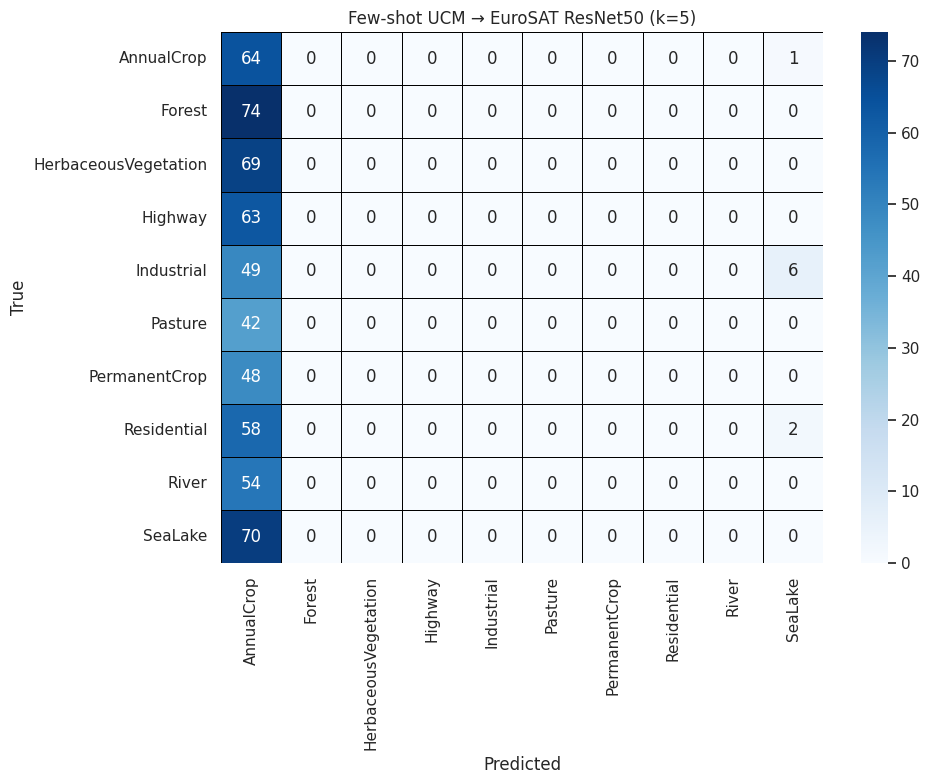

In [24]:
# k = 5
show_cm(
    cm_dict[5],
    class_names_es,
    "Few-shot UCM → EuroSAT ResNet50 (k=5)"
)



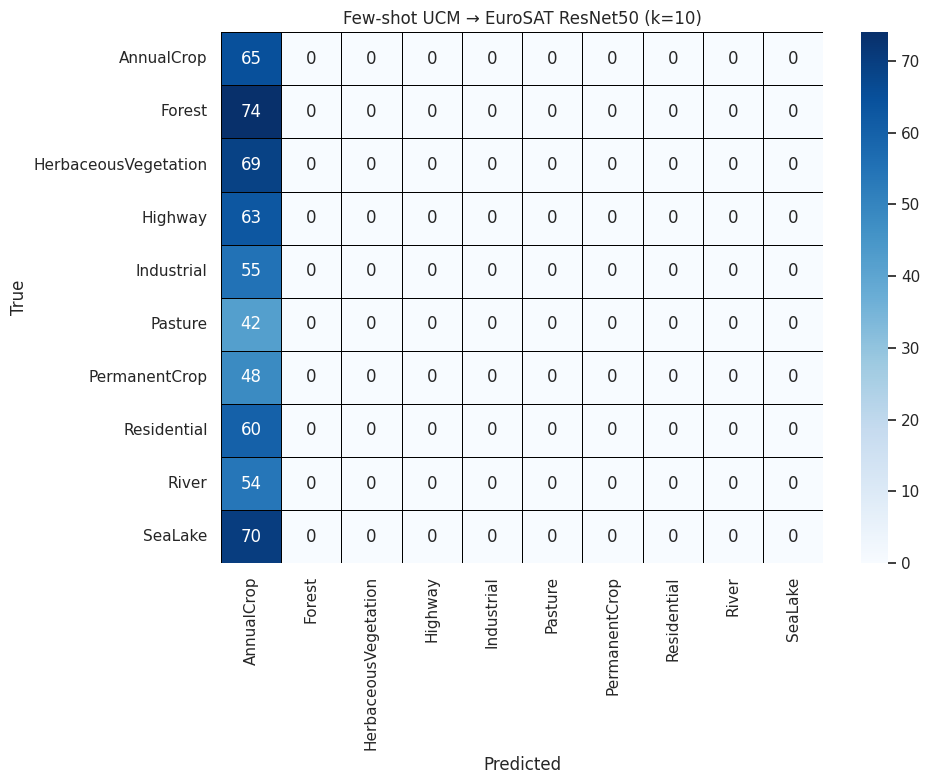

In [25]:
# k = 10
show_cm(
    cm_dict[10],
    class_names_es,
    "Few-shot UCM → EuroSAT ResNet50 (k=10)"
)



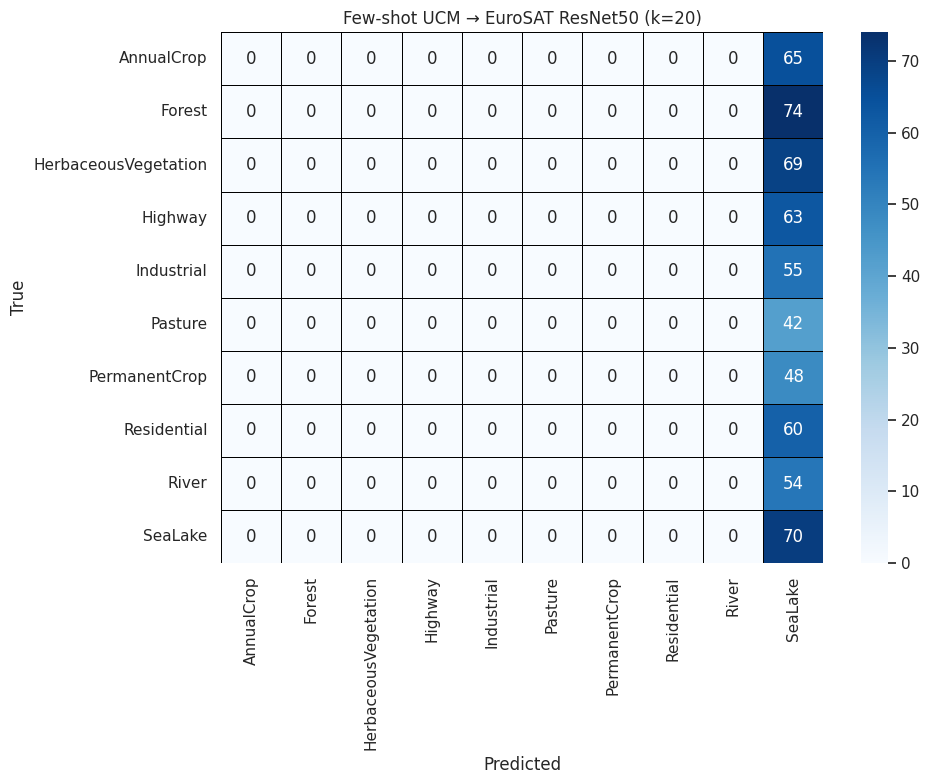

In [26]:
# k = 20
show_cm(
    cm_dict[20],
    class_names_es,
    "Few-shot UCM → EuroSAT ResNet50 (k=20)"
)
